# Insurance Linear Regression
### Dataset: `insuranceData.csv`

In this notebook, we will build a Linear Regression model to predict medical insurance `charges` based on `age`, `bmi`, `children`, and `smoker` status.

## 1. Import the libraries we will need

In [1]:
# First, let's import all the libraries we're going to use for this
# whole analysis, from handling the data up to building the model

# numpy - for number crunching, arrays, etc.
import numpy as np

# pandas - this is what we'll use to load and manage our csv file
import pandas as pd

# matplotlib and seaborn - just to visualize our data, helpful for checking things
import matplotlib.pyplot as plt
import seaborn as sns

# LabelEncoder and OneHotEncoder - to convert our categorical data (yes/no) into numbers
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# train_test_split - to split our data into training and testing sets
from sklearn.model_selection import train_test_split

# LinearRegression - this is the model we'll be using
from sklearn.linear_model import LinearRegression

# some metrics so we can see how good (or not so good) our model is
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded, let's go!")

Libraries loaded, let's go!


## 2. Load the insuranceData.csv

In [2]:
# Now let's load the actual csv file into a pandas DataFrame
insurance = pd.read_csv("insuranceData.csv")

# Let's check the first few rows so we can see what the data looks like
insurance.head()

,age,bmi,children,smoker,charges
0,19,27.900,0,yes,16884.92400
1,18,33.770,1,no,1725.55230
2,28,33.000,3,no,4449.46200
3,33,22.705,0,no,21984.47061
4,32,28.880,0,no,3866.85520


In [3]:
# Let's also check the info of the dataset - data types, any missing values, etc.
insurance.info()

# And a quick summary of the stats, just to get a feel for the numbers
insurance.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   bmi       1338 non-null   float64
 2   children  1338 non-null   int64  
 3   smoker    1338 non-null   str    
 4   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(1)
memory usage: 52.4 KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3. Explore the categorical column

Looking at this dataset, `smoker` is really the only categorical column we have (values are just `yes` or `no`). The rest — `age`, `bmi`, `children`, and `charges` — are already numeric.

In [4]:
# Let's check what unique values are in the smoker column
print(insurance['smoker'].unique())

# So we can see there are only 2 categories here: yes and no
# This is the column we'll apply LabelEncoder and OneHotEncoder to

<StringArray>
['yes', 'no']
Length: 2, dtype: str


## 4. Apply LabelEncoder() to the categorical data

We'll use `LabelEncoder` to convert the `smoker` column (currently text, yes/no) into numbers (0 and 1), so our model can actually use it later.

In [5]:
# Let's make a copy of our dataframe first, so we don't mess up the original
insurance_encoded = insurance.copy()

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the smoker column
# (yes/no will become 0/1, depending on how the encoder assigns the values)
insurance_encoded['smoker_label'] = label_encoder.fit_transform(insurance_encoded['smoker'])

# Let's check the result to make sure the conversion looks right
insurance_encoded[['smoker', 'smoker_label']].head(10)

,smoker,smoker_label
0,yes,1
1,no,0
2,no,0
3,no,0
4,no,0
5,no,0
6,no,0
7,no,0
8,no,0
9,no,0


## 5. Apply OneHotEncode() to the categorical data

Let's also show `OneHotEncoder` here, so we have an example of both techniques. Since we only have one categorical column (`smoker`), we'll apply OneHotEncoder to that same column, just to see how it's different from LabelEncoder.

In [6]:
# Initialize the OneHotEncoder
# sparse_output=False so we get back a regular array instead of a sparse matrix
onehot_encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the smoker column
# We need to reshape it since the encoder expects a 2D input
smoker_onehot = onehot_encoder.fit_transform(insurance_encoded[['smoker']])

# Convert the result into a DataFrame, and label the columns based on
# the categories (no, yes)
onehot_columns = onehot_encoder.get_feature_names_out(['smoker'])
smoker_onehot_df = pd.DataFrame(smoker_onehot, columns=onehot_columns)

# Attach this to our main dataframe
insurance_encoded = pd.concat([insurance_encoded.reset_index(drop=True), smoker_onehot_df], axis=1)

# Let's check the final result
insurance_encoded.head(10)

,age,bmi,children,smoker,charges,smoker_label,smoker_no,smoker_yes
0,19,27.900,0,yes,16884.92400,1,0.0,1.0
1,18,33.770,1,no,1725.55230,0,1.0,0.0
2,28,33.000,3,no,4449.46200,0,1.0,0.0
3,33,22.705,0,no,21984.47061,0,1.0,0.0
4,32,28.880,0,no,3866.85520,0,1.0,0.0
5,31,25.740,0,no,3756.62160,0,1.0,0.0
6,46,33.440,1,no,8240.58960,0,1.0,0.0
7,37,27.740,3,no,7281.50560,0,1.0,0.0
8,37,29.830,2,no,6406.41070,0,1.0,0.0
9,60,25.840,0,no,28923.13692,0,1.0,0.0


## 6. Set up our Features (X) and Target (y)

We'll use the one-hot encoded version of `smoker` as a feature, along with `age`, `bmi`, and `children`. `charges` is what we're trying to predict.

In [7]:
# The features we'll use: age, bmi, children, and the one-hot encoded smoker columns
X = insurance_encoded[['age', 'bmi', 'children'] + list(onehot_columns)]

# Our target variable is charges (the amount that gets billed)
y = insurance_encoded['charges']

# Just a quick check on what our features look like
X.head()

,age,bmi,children,smoker_no,smoker_yes
0,19,27.900,0,0.0,1.0
1,18,33.770,1,1.0,0.0
2,28,33.000,3,1.0,0.0
3,33,22.705,0,1.0,0.0
4,32,28.880,0,1.0,0.0


## 7. Train-Test Split (85% Train / 15% Test)

Based on the requirement, 15% of our data should be set aside as the test set, and the remaining 85% is for training.

In [8]:
# test_size=0.15 means we're setting aside 15% of the full dataset for
# testing, and the remaining 85% is for training the model
# random_state is set so we get the same split every time we run this
# (keeps our results consistent)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Let's check the size of each set, just to make sure the split looks right
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size:  {X_test.shape[0]} rows")

Training set size: 1137 rows
Testing set size:  201 rows


## 8. Train the Linear Regression Model

In [9]:
# Initialize the Linear Regression model
model = LinearRegression()

# Now let's fit/train it using our training data
model.fit(X_train, y_train)

print("Model training done, let's check the coefficients.")

# Let's look at the coefficients of the model, so we know how much
# each feature affects the charges
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")

print(f"\nIntercept: {model.intercept_:.2f}")

Model training done, let's check the coefficients.
age: 260.38
bmi: 316.75
children: 424.38
smoker_no: -11880.35
smoker_yes: 11880.35

Intercept: -43.70


## 9. Evaluate the Model using the Test Set

In [10]:
# Let's use our model to make predictions on the test set
y_pred = model.predict(X_test)

# Some common metrics to see how well the model performed:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE):  {mae:.2f}")
print(f"Mean Squared Error (MSE):  {mse:.2f}")
print(f"Root Mean Squared Error:   {rmse:.2f}")
print(f"R-squared (R2):            {r2:.4f}")

# Basically, the closer our R2 score is to 1, the better the model fits
# the data. For MAE and RMSE, lower is better since it means our
# predictions are closer to the actual values.

Mean Absolute Error (MAE):  4084.84
Mean Squared Error (MSE):  31416287.36
Root Mean Squared Error:   5605.02
R-squared (R2):            0.7937


## 10. Visualize: Actual vs Predicted Charges

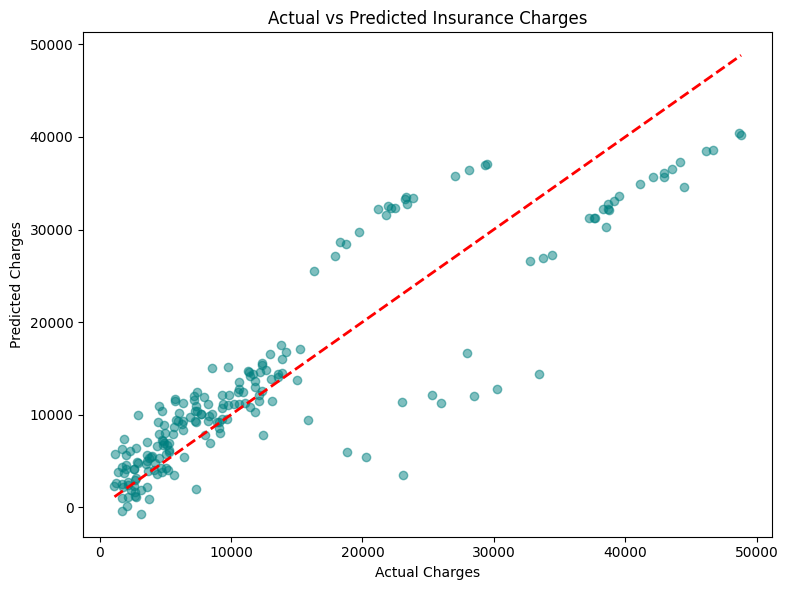

In [11]:
# Let's make a simple scatter plot to see how close our predictions are
# to the actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.tight_layout()
plt.show()

# That red dashed line is the "perfect prediction" line.
# If our points are close to it, that means the model's predictions are
# pretty good. If they're scattered further away, that just means there's
# still room for improvement (maybe try different features or a different
# model).

## Summary

- We loaded `insuranceData.csv` and applied both `LabelEncoder` and `OneHotEncoder` to the `smoker` column, since that's the only categorical variable in the dataset.
- We used `age`, `bmi`, `children`, and the encoded `smoker` columns as features, with `charges` as the target.
- We split the data into 85% training and 15% testing.
- We trained a Linear Regression model and evaluated it using MAE, MSE, RMSE, and R-squared.
- Finally, we visualized actual vs predicted charges to see how well the model actually performed.